# Regression Plots with Seaborn

`import seaborn as sns` brings in the seaborn library, a plotting toolkit built on top of matplotlib that makes it easier to draw statistical graphs like scatter plots and regression lines. `import matplotlib.pyplot as plt` brings in matplotlib's plotting interface, which seaborn uses under the hood to actually draw and display the figures.

**Usecase:** These two imports are needed before we can call any `sns.lmplot()` plotting function later in the notebook.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Linear Model Plots (lmplot)

*Regression plots are used in machine learning so we will not fully discuss what, how and where they are used, but we will see how they are created and what are the values we can put inside them.*

Regression plots help us visualize linear relationships between variables and are essential for understanding correlations in data.

### Loading the Dataset

`sns.load_dataset(name)` loads one of seaborn's built-in sample datasets by name and returns it as a pandas DataFrame. It's a quick way to get realistic tabular data to practice plotting with, without needing your own CSV file.

**Usecase:** Here it loads the `tips` dataset, which has columns like `total_bill`, `tip`, and `sex`, giving us real numbers to plot regression lines against for the rest of this notebook.

In [2]:
tips = sns.load_dataset("tips")
print("Dataset shape:", tips.shape)
print("\nDataset info:")
tips.info()
print("\nFirst few rows:")
tips.head()

Dataset shape: (244, 7)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

First few rows:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Basic Linear Model Plot

`sns.lmplot(x=..., y=..., data=...)` draws a scatter plot of two columns and then fits and draws a straight regression line through the points, with a shaded band around it showing the uncertainty of that fit. It's seaborn's go-to function for checking whether two numeric columns have a linear relationship, and it runs the underlying regression math for you automatically.

**Usecase:** Used here to check whether `total_bill` and `tip` are related, in other words whether bigger bills tend to come with bigger tips, by plotting those two columns from the `tips` dataset with a fitted trend line on top.

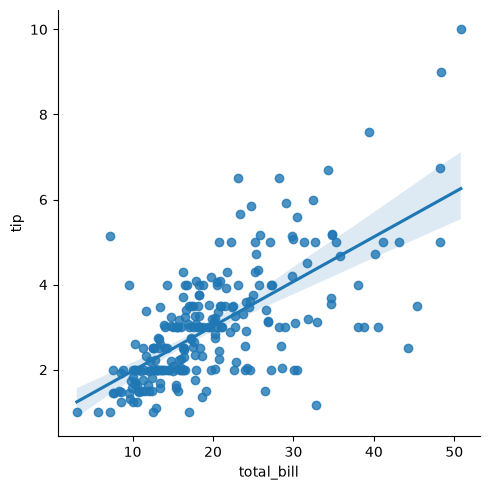

In [3]:
sns.lmplot(x='total_bill', y='tip', data=tips)
plt.show()

### Linear Model Plot with Hue

The `hue` argument in `sns.lmplot()` splits the data into separate groups based on the values of a column, then draws a separate scatter plot and a separate regression line for each group, each in a different color. This lets you compare whether the relationship between the two numeric columns looks different across categories.

**Usecase:** Adding `hue='sex'` here draws one regression line for male customers and one for female customers, so you can see whether the `total_bill` vs `tip` relationship differs between the two groups.

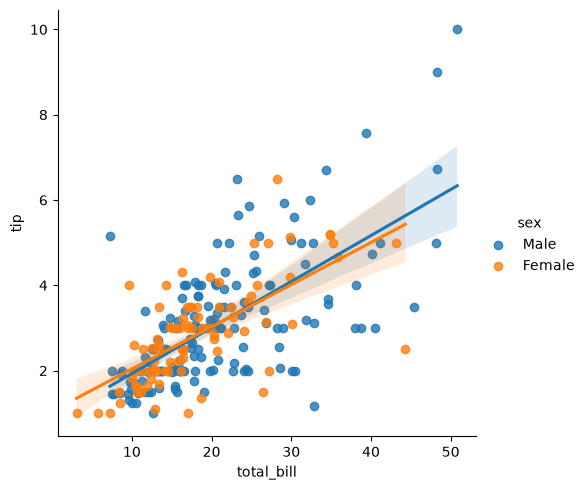

In [4]:
sns.lmplot(x='total_bill', y='tip', data=tips, hue='sex')
plt.show()

### Customizing Colors with Palette

The `palette` argument controls which set of colors seaborn uses to tell the `hue` groups apart. `'coolwarm'` is one of matplotlib/seaborn's built-in named color palettes, running from cool blue tones to warm red tones. It only changes how the groups are colored, not the underlying data or the fitted lines.

**Usecase:** Here it just recolors the two `sex` groups from the previous plot using the coolwarm palette, making the male and female lines easier to tell apart visually.

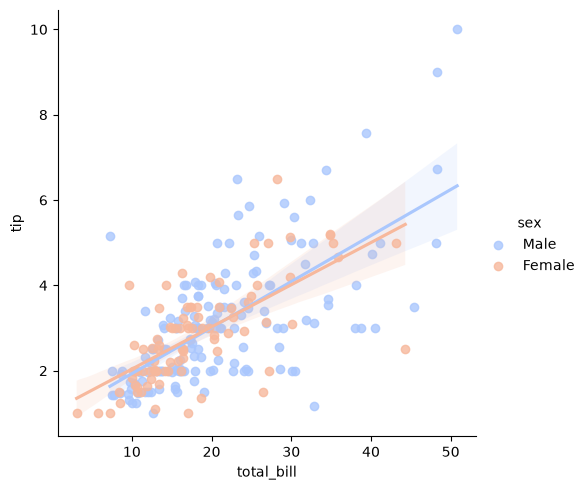

In [5]:
sns.lmplot(x='total_bill', y='tip', data=tips, hue='sex', palette='coolwarm')
plt.show()

### Advanced Customization with Markers and Scatter Keywords

The `markers` argument gives each `hue` group its own point shape, for example `'o'` for a circle and `'v'` for a downward triangle, on top of the different colors, which helps when colors alone are hard to tell apart. `scatter_kws` is a dictionary of extra settings passed straight through to the underlying scatter plot; here `{'s': 50}` sets the size of each point to 50.

**Usecase:** Used here so the male and female points in the `total_bill` vs `tip` plot are distinguished by both shape and color, with slightly bigger dots for better visibility.

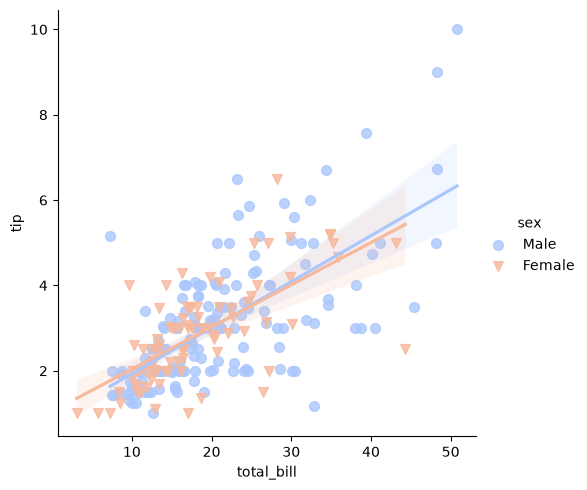

In [6]:
sns.lmplot(x='total_bill', y='tip', data=tips, hue='sex', palette='coolwarm', 
           markers=['o', 'v'], scatter_kws={'s': 50})
plt.show()

## Additional Regression Plot Examples

Let's explore some additional features and variations of regression plots.

### Regression Plot by Time of Day

Let's see how the relationship changes based on the time of day (Lunch vs Dinner):

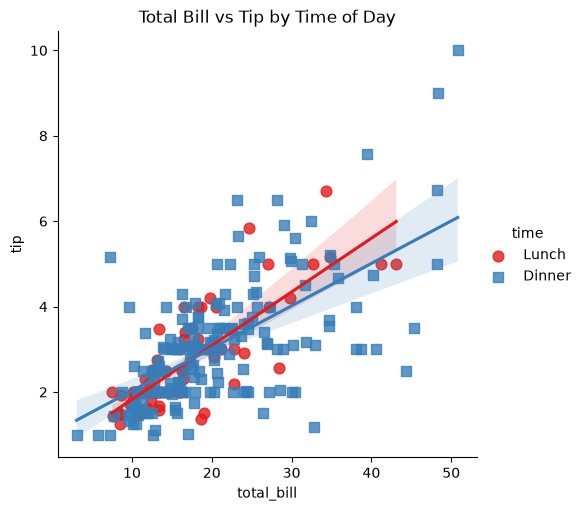

In [7]:
sns.lmplot(x='total_bill', y='tip', data=tips, hue='time', palette='Set1', 
           markers=['o', 's'], scatter_kws={'s': 60})
plt.title('Total Bill vs Tip by Time of Day')
plt.show()

### Regression Plot with Column and Row Facets

We can create separate plots for different categories using `col` and `row` parameters:

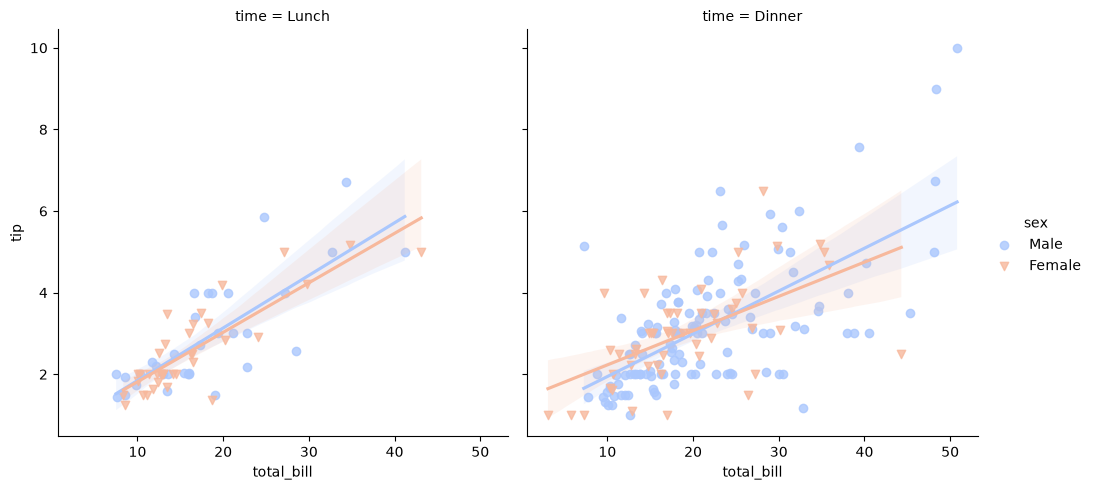

In [8]:
sns.lmplot(x='total_bill', y='tip', data=tips, col='time', hue='sex', 
           palette='coolwarm', markers=['o', 'v'])
plt.show()

### Regression Plot by Day of Week

Let's create separate plots for each day of the week:

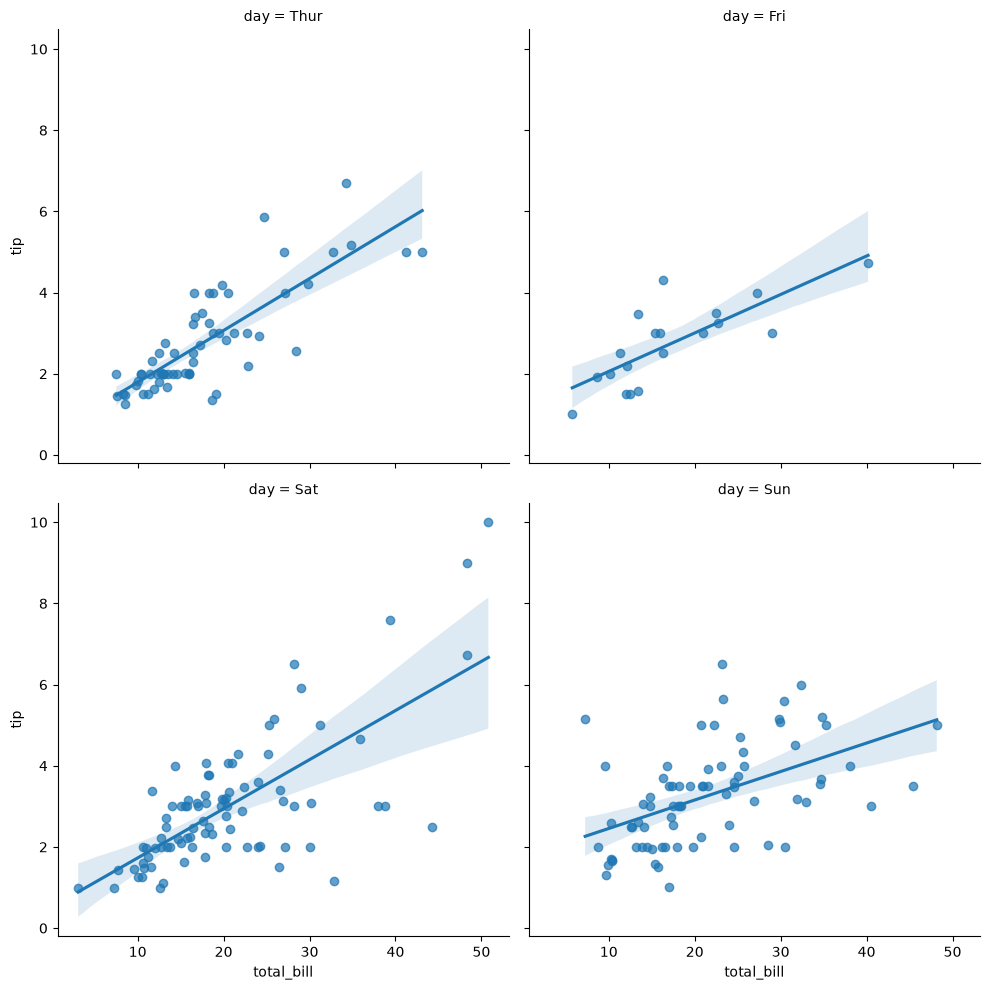

In [9]:
sns.lmplot(x='total_bill', y='tip', data=tips, col='day', col_wrap=2, 
           palette='viridis', scatter_kws={'alpha': 0.7})
plt.show()

### Regression Plot with Different Aspect Ratio

We can control the size and aspect ratio of the plots:

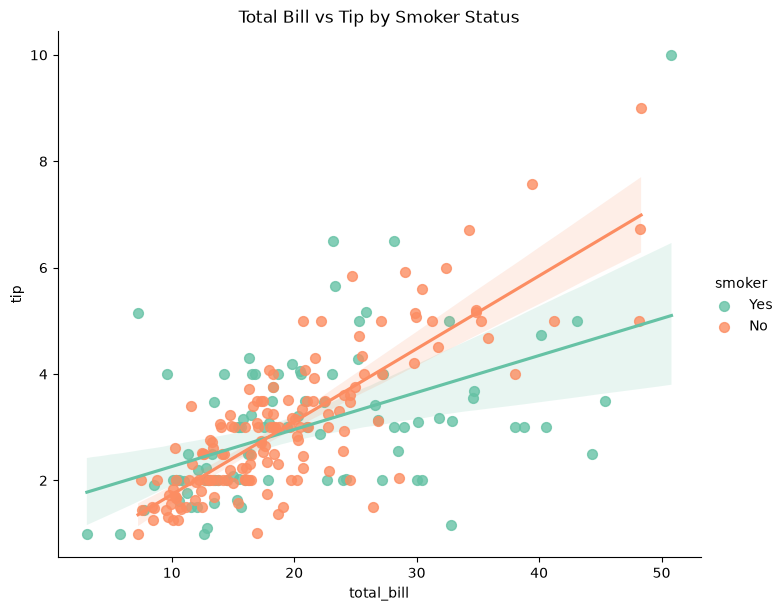

In [10]:
sns.lmplot(x='total_bill', y='tip', data=tips, hue='smoker', 
           palette='Set2', height=6, aspect=1.2, 
           scatter_kws={'s': 50, 'alpha': 0.8})
plt.title('Total Bill vs Tip by Smoker Status')
plt.show()

## Alternative Regression Plot Functions

Seaborn also provides other functions for regression plots:

### Using regplot for Simple Regression

`sns.regplot()` is similar to `lmplot()` but works on the current matplotlib axes, making it easier to combine with other plots:

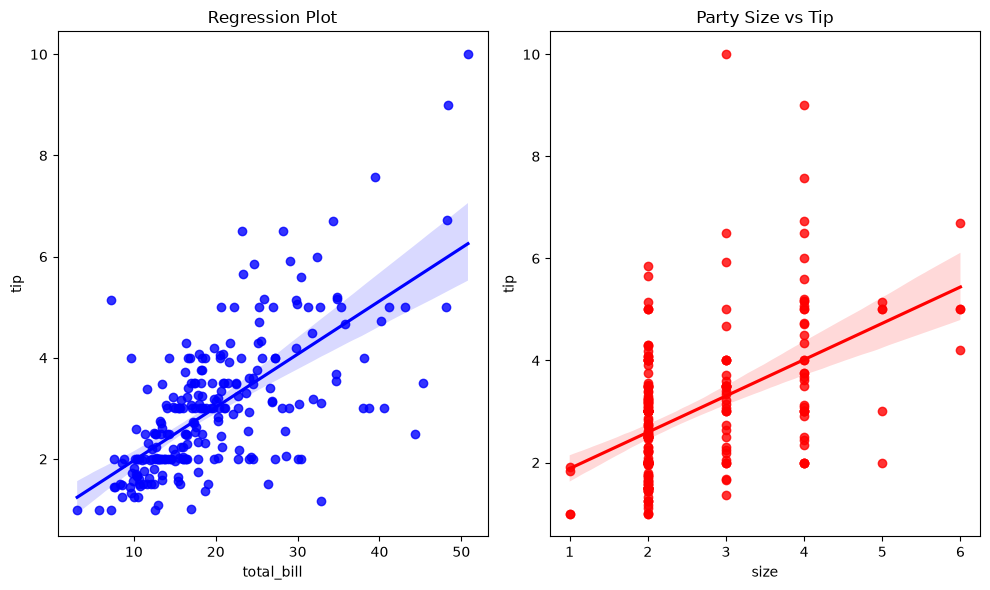

In [11]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.regplot(x='total_bill', y='tip', data=tips, color='blue')
plt.title('Regression Plot')

plt.subplot(1, 2, 2)
sns.regplot(x='size', y='tip', data=tips, color='red')
plt.title('Party Size vs Tip')

plt.tight_layout()
plt.show()

### Residual Plot

Residual plots help us check the assumptions of linear regression:

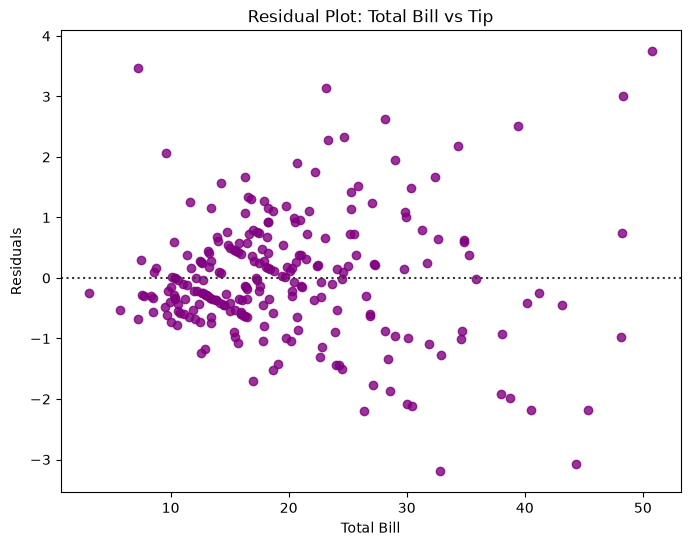

In [12]:
plt.figure(figsize=(8, 6))
sns.residplot(x='total_bill', y='tip', data=tips, color='purple')
plt.title('Residual Plot: Total Bill vs Tip')
plt.xlabel('Total Bill')
plt.ylabel('Residuals')
plt.show()

## Summary

In this notebook, we explored regression plots using seaborn:

1. **lmplot()**: Creates regression plots with automatic figure management
   - Basic scatter plot with regression line
   - Grouping by categorical variables with `hue`
   - Customizing colors, markers, and point sizes
   - Creating faceted plots with `col` and `row`

2. **regplot()**: Creates regression plots on existing axes
   - More flexible for subplot arrangements
   - Good for combining multiple regression plots

3. **residplot()**: Creates residual plots for regression diagnostics
   - Helps check linear regression assumptions
   - Identifies patterns in residuals

These plots are essential for:
- Exploring linear relationships between variables
- Comparing relationships across different groups
- Validating regression model assumptions
- Communicating statistical findings visually